# MLP Architecture Search — Adriatic_Sea & DRYAD holdouts

Explores MLP architecture variants on the two best continuous-audio folds.
All other pipeline code (calibrators, metrics, LODO runner) is identical
to notebook 4 (the current best).

## What varies across configs
| axis | values |
|---|---|
| hidden layers | `(512,256)` · `(256,128)` · `(512,256,128)` · `(256,)` |
| batch norm | off · on |
| lr + scheduler | flat 1e-3 · flat 5e-4 · cosine 1e-3→0 |
| focal loss γ | 0 (CE) · 1.0 · 2.0 |

Primary metrics: **species recall** and **hallucination rate** (argmax strategy).
F1 and temperature also tracked as secondary signals.

Holdouts: **Adriatic_Sea** (easy fold, recall ~0.78) and **DRYAD** (harder fold, recall ~0.65).
A config must improve on *both* to be considered a real gain.

## 0. Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path
from itertools import product as iterproduct

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_recall_curve,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")

device: cuda  torch: 2.5.1+cu121


In [2]:
IN_DIR  = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')
PROJ_IN = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')
OUT_DIR = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/arch_search')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

# Only these two holdouts evaluated in this notebook
SEARCH_HOLDOUTS = ['Adriatic_Sea', 'DRYAD']

print(f"meta:  {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all: {X_PATH}     exists={X_PATH.exists()}")
print(f"out:   {OUT_DIR.resolve()}")

meta:  /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all: /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
out:   /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/arch_search


In [3]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')

EXCLUDE = {'ALNITAK_CAVANILLES', 'FREMANTLE', 'ECOSS_enhanced'}
meta_all = meta_all[~meta_all['dataset'].isin(EXCLUDE)].reset_index(drop=True)

print(f"meta_all: {len(meta_all):,} rows")
print(f"X_all:    {X_all.shape}  dtype={X_all.dtype}")

assert 'row' in meta_all.columns
assert 'group_key' in meta_all.columns
assert meta_all['row'].max() < len(X_all)
for c in ['label_t1','label_t2','label_t3','label_t4','label_t5']:
    assert c in meta_all.columns, f"missing: {c}"

ALL_DATASETS = sorted(meta_all['dataset'].unique().tolist())
print(f"datasets ({len(ALL_DATASETS)}): {ALL_DATASETS}")

meta_all: 241,928 rows
X_all:    (247630, 1536)  dtype=float32
datasets (9): ['Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_testtrain', 'MONISH', 'OLTREMARE', 'WATKINS']


## 1. Label frames

In [4]:
def build_l4(row):
    t4 = row['label_t4']
    if pd.notna(t4): return t4
    t1 = row['label_t1']; t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'): return 'background'
    return None

meta_l4 = meta_all.copy()
meta_l4['label'] = meta_l4.apply(build_l4, axis=1)
meta_l4 = meta_l4.dropna(subset=['label']).copy()
print(f"L4: {len(meta_l4):,} rows")
print(meta_l4['label'].value_counts().to_string())

L4: 241,928 rows
label
background                    209233
Orcinus_orca                   21794
Tursiops_truncatus              6833
Delphinus_delphis               1292
Physeter_macrocephalus           895
Globicephala_melas               580
Balaenoptera_physalus            539
Delphinidae_unknown              466
Grampus_griseus                  194
Stenella_coeruleoalba             85
Balaenoptera_acutorostrata        17


## 2. Model definitions

Two variants:
- `MLP` — plain Linear → ReLU → Dropout (baseline, same as nb4)
- `MLPwithBN` — Linear → BN → ReLU → Dropout (batch-norm variant)

In [6]:
class MLP(nn.Module):
    """Baseline MLP — identical to notebook 4."""
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


class MLPwithBN(nn.Module):
    """MLP with BatchNorm before each activation."""
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

## 3. Training function

Supports:
- `scheduler`: `None` (flat lr), `'cosine'` (CosineAnnealingLR)
- `focal_gamma`: `0.0` → standard cross-entropy; `>0` → focal loss
- `use_bn`: selects `MLPwithBN` vs `MLP`

In [7]:
def focal_cross_entropy(logits, targets, gamma=2.0, weight=None):
    """Focal loss: (1 - p_t)^gamma * CE.  gamma=0 reduces to standard CE."""
    ce  = F.cross_entropy(logits, targets, weight=weight, reduction='none')
    pt  = torch.exp(-ce)
    return ((1 - pt) ** gamma * ce).mean()


def train_mlp_cfg(Xtr, ytr, Xva, yva, n_classes, cfg):
    """
    Train with a config dict.  Keys (all optional with defaults):
        hidden       : tuple of ints          default (512, 256)
        dropout      : float                  default 0.3
        lr           : float                  default 1e-3
        weight_decay : float                  default 1e-4
        batch_size   : int                    default 1024
        epochs       : int                    default 60
        patience     : int                    default 8
        class_weight : bool                   default True
        use_bn       : bool                   default False
        scheduler    : None | 'cosine'        default None
        focal_gamma  : float                  default 0.0  (=CE)
    """
    hidden       = cfg.get('hidden',       (512, 256))
    dropout      = cfg.get('dropout',      0.3)
    lr           = cfg.get('lr',           1e-3)
    weight_decay = cfg.get('weight_decay', 1e-4)
    batch_size   = cfg.get('batch_size',   1024)
    epochs       = cfg.get('epochs',       60)
    patience     = cfg.get('patience',     8)
    class_weight = cfg.get('class_weight', True)
    use_bn       = cfg.get('use_bn',       False)
    sched_type   = cfg.get('scheduler',    None)
    focal_gamma  = cfg.get('focal_gamma',  0.0)

    ModelCls = MLPwithBN if use_bn else MLP
    model = ModelCls(Xtr.shape[1], n_classes, hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    if sched_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=0)
    else:
        scheduler = None

    if class_weight:
        counts = np.bincount(ytr, minlength=n_classes).astype(np.float32)
        w      = counts.sum() / (n_classes * np.clip(counts, 1, None))
        cw_t   = torch.tensor(w, dtype=torch.float32, device=DEVICE)
    else:
        cw_t = None

    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=batch_size, shuffle=False, num_workers=0)

    best_f1, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            if focal_gamma > 0:
                loss = focal_cross_entropy(model(xb), yb, gamma=focal_gamma, weight=cw_t)
            else:
                loss = F.cross_entropy(model(xb), yb, weight=cw_t)
            loss.backward()
            opt.step()
        if scheduler is not None:
            scheduler.step()

        model.eval(); preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
                trues.append(yb.numpy())
        va_f1 = f1_score(np.concatenate(trues), np.concatenate(preds),
                         average='macro', zero_division=0)
        if va_f1 > best_f1 + 1e-4:
            best_f1    = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_f1


def get_logits(model, X, batch_size=2048):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            out.append(model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out, axis=0)

## 4. Calibrators (unchanged from nb4)

In [8]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))
    def forward(self, logits): return logits / self.log_T.exp()
    def fit(self, logits_val, y_val, lr=0.01, max_iter=200):
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)
        opt = torch.optim.LBFGS([self.log_T], lr=lr, max_iter=max_iter)
        def closure():
            opt.zero_grad()
            F.cross_entropy(self.forward(logits_t), labels_t).backward()
            return F.cross_entropy(self.forward(logits_t), labels_t)
        opt.step(closure)
        return self
    @property
    def T(self): return self.log_T.exp().item()


class VectorScaler(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.w = nn.Parameter(torch.ones(n_classes))
        self.b = nn.Parameter(torch.zeros(n_classes))
    def forward(self, logits):
        return logits * self.w + self.b
    def fit(self, logits_val, y_val, lr=0.01, max_iter=500, l2=1e-3):
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)
        counts   = np.bincount(y_val, minlength=self.w.shape[0]).astype(np.float32)
        weights  = counts.sum() / (self.w.shape[0] * np.clip(counts, 1, None))
        cw_t     = torch.tensor(weights, dtype=torch.float32)
        opt = torch.optim.LBFGS([self.w, self.b], lr=lr, max_iter=max_iter)
        def closure():
            opt.zero_grad()
            nll = F.cross_entropy(self.forward(logits_t), labels_t, weight=cw_t)
            reg = l2 * ((self.w - 1).pow(2).sum() + self.b.pow(2).sum())
            (nll + reg).backward()
            return nll + reg
        opt.step(closure)
        return self


def calibrate_and_predict(logits, calibrator):
    with torch.no_grad():
        cal   = calibrator(torch.tensor(logits, dtype=torch.float32))
        proba = F.softmax(cal, dim=1).numpy()
    return proba.argmax(axis=1), proba


def fit_pr_thresholds(proba_val, y_val, class_names, bg_idx, min_thr=0.01):
    thresholds = {}
    for cls_idx, cls_name in enumerate(class_names):
        if cls_idx == bg_idx:
            thresholds[cls_name] = 0.0; continue
        y_bin = (y_val == cls_idx).astype(int)
        if y_bin.sum() == 0:
            thresholds[cls_name] = 0.5; continue
        precs, recs, thrs = precision_recall_curve(y_bin, proba_val[:, cls_idx])
        f1s   = 2 * precs * recs / np.clip(precs + recs, 1e-9, None)
        f1s   = f1s[:-1]
        valid = thrs >= min_thr
        if valid.sum() == 0:
            thresholds[cls_name] = 0.5; continue
        thresholds[cls_name] = float(thrs[valid][np.argmax(f1s[valid])])
    return thresholds


def predict_with_pr_thresholds(proba, class_names, thresholds, bg_idx):
    qualify = np.zeros(proba.shape, dtype=bool)
    for cls_idx, cls_name in enumerate(class_names):
        if cls_idx == bg_idx:
            qualify[:, cls_idx] = True; continue
        qualify[:, cls_idx] = proba[:, cls_idx] >= thresholds.get(cls_name, 0.5)
    return np.where(qualify, proba, -np.inf).argmax(axis=1)

## 5. Metrics (unchanged from nb4)

In [9]:
def compute_species_metrics(y_true, y_pred, class_names, bg_label):
    bg_idx     = class_names.index(bg_label) if bg_label in class_names else -1
    all_sp_idx = set(i for i, c in enumerate(class_names) if i != bg_idx)
    sp_mask    = (y_true != bg_idx)
    sp_present = sorted(np.unique(y_true[sp_mask]).tolist())
    sp_absent  = all_sp_idx - set(sp_present)
    if sp_mask.sum() == 0:
        return {k: None for k in [
            'sp_macro_f1','sp_recall','sp_precision',
            'sp_inter_confusion_rate','sp_hallucination_rate','sp_n_rows'
        ]}
    yt = y_true[sp_mask]; yp = y_pred[sp_mask]; n = len(yt)
    return {
        'sp_macro_f1':             float(f1_score(yt, yp, average='macro',
                                                  labels=sp_present, zero_division=0)),
        'sp_recall':               float(recall_score(yt, yp, average='macro',
                                                      labels=sp_present, zero_division=0)),
        'sp_precision':            float(precision_score(yt, yp, average='macro',
                                                         labels=sp_present, zero_division=0)),
        'sp_inter_confusion_rate': float(((yp != yt) & np.isin(yp, list(all_sp_idx))).sum() / n),
        'sp_hallucination_rate':   float(np.isin(yp, list(sp_absent)).sum() / n),
        'sp_n_rows':               int(n),
    }


def per_class_f1(y_true, y_pred, class_names):
    n   = len(class_names)
    f1s = f1_score(y_true, y_pred, labels=list(range(n)), average=None, zero_division=0)
    return {class_names[i]: float(f1s[i]) for i in range(n)}

## 6. LODO runner — config-aware version

In [10]:
def split_train_val(meta_subset, val_size=0.12, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    tr_pos, va_pos = next(gss.split(np.zeros(len(meta_subset)),
                                    groups=meta_subset['group_key'].values))
    return tr_pos, va_pos


def run_one_fold(held_out, meta_df, cfg,
                 label_col='label', bg_label='background',
                 min_train_per_class=5, val_size=0.12, verbose=False):
    """
    Single LODO fold with a given architecture config.
    Returns a flat dict of key metrics + model artefacts.
    """
    train_meta = meta_df[meta_df['dataset'] != held_out].copy()
    test_meta  = meta_df[meta_df['dataset'] == held_out].copy()

    counts     = train_meta[label_col].value_counts()
    train_keep = set(counts[counts >= min_train_per_class].index)
    test_keep  = set(test_meta[label_col].unique()) & train_keep

    if len(train_keep) < 2 or len(test_keep) < 1:
        return None

    train_meta = train_meta[train_meta[label_col].isin(train_keep)].copy()
    test_meta  = test_meta [test_meta [label_col].isin(test_keep )].copy()

    le = LabelEncoder().fit(sorted(train_keep))
    train_meta = train_meta.assign(y=le.transform(train_meta[label_col].astype(str)))
    test_meta  = test_meta .assign(y=le.transform(test_meta [label_col].astype(str)))
    class_names = list(le.classes_)
    n_cls       = len(class_names)
    bg_idx      = class_names.index(bg_label) if bg_label in class_names else -1

    tr_pos, va_pos = split_train_val(train_meta, val_size=val_size)
    rows_tr = train_meta.iloc[tr_pos]['row'].values
    rows_va = train_meta.iloc[va_pos]['row'].values
    rows_te = test_meta['row'].values

    sc    = StandardScaler().fit(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xtr_s = sc.transform(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xva_s = sc.transform(np.asarray(X_all[rows_va], dtype=np.float32))
    Xte_s = sc.transform(np.asarray(X_all[rows_te], dtype=np.float32))
    ytr   = train_meta.iloc[tr_pos]['y'].values.astype(np.int64)
    yva   = train_meta.iloc[va_pos]['y'].values.astype(np.int64)
    yte   = test_meta['y'].values

    t0             = time.time()
    model, best_va = train_mlp_cfg(Xtr_s, ytr, Xva_s, yva, n_classes=n_cls, cfg=cfg)
    elapsed        = time.time() - t0

    logits_va = get_logits(model, Xva_s)
    logits_te = get_logits(model, Xte_s)

    # Argmax
    proba_raw = torch.softmax(torch.tensor(logits_te), dim=1).numpy()
    y_argmax  = proba_raw.argmax(axis=1)

    # Temperature
    temp_scaler = TemperatureScaler()
    temp_scaler.fit(logits_va, yva)
    y_temp, proba_temp = calibrate_and_predict(logits_te, temp_scaler)

    # Vector scaling
    vec_scaler = VectorScaler(n_cls)
    vec_scaler.fit(logits_va, yva, l2=1e-3)
    y_vec, proba_vec = calibrate_and_predict(logits_te, vec_scaler)

    # PR threshold
    proba_va_raw  = torch.softmax(torch.tensor(logits_va), dim=1).numpy()
    pr_thresholds = fit_pr_thresholds(proba_va_raw, yva, class_names, bg_idx)
    y_pr_thresh   = predict_with_pr_thresholds(proba_raw, class_names, pr_thresholds, bg_idx)

    sp_a = compute_species_metrics(yte, y_argmax,    class_names, bg_label)
    sp_v = compute_species_metrics(yte, y_vec,       class_names, bg_label)
    sp_p = compute_species_metrics(yte, y_pr_thresh, class_names, bg_label)

    if verbose:
        print(f"  [{held_out}] T={temp_scaler.T:.3f}  val_f1={best_va:.4f}  "
              f"elapsed={elapsed:.1f}s")
        print(f"  [{held_out}] argmax recall={sp_a['sp_recall']:.3f}  "
              f"hallucin={sp_a['sp_hallucination_rate']:.3f}")

    return {
        'held_out':        held_out,
        'class_names':     class_names,
        'n_cls':           n_cls,
        'bg_idx':          bg_idx,
        'val_macro_f1':    float(best_va),
        'elapsed_s':       float(elapsed),
        'temperature':     float(temp_scaler.T),
        'pr_thresholds':   pr_thresholds,
        'yte':             yte,
        # argmax
        'y_argmax':        y_argmax,
        'sp_argmax':       sp_a,
        'pc_f1_argmax':    per_class_f1(yte, y_argmax,    class_names),
        # vec
        'y_vec':           y_vec,
        'sp_vec':          sp_v,
        # pr_thresh
        'y_pr_thresh':     y_pr_thresh,
        'sp_pr_thresh':    sp_p,
        # raw probs for downstream analysis
        'proba_raw':       proba_raw,
    }

## 7. Architecture grid definition

Each config is a named dict understood by `train_mlp_cfg`.
The **baseline** exactly replicates nb4 so its numbers here should match
the nb4 Adriatic / DRYAD results.

In [11]:
CONFIGS = {
    # ── BASELINE (nb4 winner) ───────────────────────────────────────────────
    'baseline':           {'hidden': (512, 256),     'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': False, 'scheduler': None,     'focal_gamma': 0.0},

    # ── Architecture: narrower / shallower ─────────────────────────────────
    'narrow_1layer':      {'hidden': (256,),          'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': False, 'scheduler': None,     'focal_gamma': 0.0},
    'narrow_2layer':      {'hidden': (256, 128),      'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': False, 'scheduler': None,     'focal_gamma': 0.0},
    'deep_3layer':        {'hidden': (512, 256, 128), 'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': False, 'scheduler': None,     'focal_gamma': 0.0},

    # ── Batch norm ──────────────────────────────────────────────────────────
    'baseline_bn':        {'hidden': (512, 256),      'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': True,  'scheduler': None,     'focal_gamma': 0.0},
    'narrow_2layer_bn':   {'hidden': (256, 128),      'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': True,  'scheduler': None,     'focal_gamma': 0.0},

    # ── Learning rate / scheduler ───────────────────────────────────────────
    'baseline_lr5e4':     {'hidden': (512, 256),      'dropout': 0.3,  'lr': 5e-4,
                           'use_bn': False, 'scheduler': None,     'focal_gamma': 0.0},
    'baseline_cosine':    {'hidden': (512, 256),      'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': False, 'scheduler': 'cosine', 'focal_gamma': 0.0},
    'baseline_cosine5e4': {'hidden': (512, 256),      'dropout': 0.3,  'lr': 5e-4,
                           'use_bn': False, 'scheduler': 'cosine', 'focal_gamma': 0.0},

    # ── Focal loss ──────────────────────────────────────────────────────────
    'focal_g1':           {'hidden': (512, 256),      'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': False, 'scheduler': None,     'focal_gamma': 1.0},
    'focal_g2':           {'hidden': (512, 256),      'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': False, 'scheduler': None,     'focal_gamma': 2.0},

    # ── Best combos (cosine + bn, cosine + focal) ───────────────────────────
    'bn_cosine':          {'hidden': (512, 256),      'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': True,  'scheduler': 'cosine', 'focal_gamma': 0.0},
    'focal_g1_cosine':    {'hidden': (512, 256),      'dropout': 0.3,  'lr': 1e-3,
                           'use_bn': False, 'scheduler': 'cosine', 'focal_gamma': 1.0},
}

print(f"{len(CONFIGS)} configs × {len(SEARCH_HOLDOUTS)} folds = "
      f"{len(CONFIGS)*len(SEARCH_HOLDOUTS)} runs")

13 configs × 2 folds = 26 runs


## 8. Run the grid

In [12]:
# Results stored as: all_results[config_name][held_out] = fold_result_dict
all_results = {}

total = len(CONFIGS) * len(SEARCH_HOLDOUTS)
done  = 0

for cfg_name, cfg in CONFIGS.items():
    all_results[cfg_name] = {}
    print(f"\n{'─'*60}")
    print(f"Config: {cfg_name}")
    print(f"  {cfg}")
    for held_out in SEARCH_HOLDOUTS:
        r = run_one_fold(
            held_out, meta_l4, cfg,
            label_col='label', bg_label='background',
            verbose=True
        )
        if r is not None:
            all_results[cfg_name][held_out] = r
        done += 1
        print(f"  [{done}/{total}] {cfg_name} / {held_out} done")

print("\n✓ Grid complete.")


────────────────────────────────────────────────────────────
Config: baseline
  {'hidden': (512, 256), 'dropout': 0.3, 'lr': 0.001, 'use_bn': False, 'scheduler': None, 'focal_gamma': 0.0}
  [Adriatic_Sea] T=1.326  val_f1=0.8638  elapsed=41.6s
  [Adriatic_Sea] argmax recall=0.691  hallucin=0.020
  [1/26] baseline / Adriatic_Sea done
  [DRYAD] T=1.425  val_f1=0.8303  elapsed=37.6s
  [DRYAD] argmax recall=0.656  hallucin=0.217
  [2/26] baseline / DRYAD done

────────────────────────────────────────────────────────────
Config: narrow_1layer
  {'hidden': (256,), 'dropout': 0.3, 'lr': 0.001, 'use_bn': False, 'scheduler': None, 'focal_gamma': 0.0}
  [Adriatic_Sea] T=1.338  val_f1=0.8760  elapsed=44.5s
  [Adriatic_Sea] argmax recall=0.615  hallucin=0.040
  [3/26] narrow_1layer / Adriatic_Sea done
  [DRYAD] T=1.518  val_f1=0.8823  elapsed=90.9s
  [DRYAD] argmax recall=0.550  hallucin=0.222
  [4/26] narrow_1layer / DRYAD done

────────────────────────────────────────────────────────────
Config:

## 9. Summary table

In [13]:
summary_rows = []

for cfg_name, fold_results in all_results.items():
    for held_out, r in fold_results.items():
        sa = r['sp_argmax']
        sv = r['sp_vec']
        sp = r['sp_pr_thresh']
        summary_rows.append({
            'config':             cfg_name,
            'held_out':           held_out,
            'val_macro_f1':       round(r['val_macro_f1'],  4),
            'temperature':        round(r['temperature'],   3),
            'elapsed_s':          round(r['elapsed_s'],     1),
            # argmax — primary metrics
            'recall_argmax':      round(sa['sp_recall'],              4),
            'hallucin_argmax':    round(sa['sp_hallucination_rate'],  4),
            'sp_f1_argmax':       round(sa['sp_macro_f1'],            4),
            'inter_conf_argmax':  round(sa['sp_inter_confusion_rate'],4),
            # vec
            'recall_vec':         round(sv['sp_recall'],              4),
            'hallucin_vec':       round(sv['sp_hallucination_rate'],  4),
            # pr_thresh
            'recall_pr':          round(sp['sp_recall'],              4),
            'hallucin_pr':        round(sp['sp_hallucination_rate'],  4),
        })

summary = pd.DataFrame(summary_rows)

# Save
summary.to_csv(OUT_DIR / 'arch_search_summary.csv', index=False)
print(summary.to_string(index=False))

            config     held_out  val_macro_f1  temperature  elapsed_s  recall_argmax  hallucin_argmax  sp_f1_argmax  inter_conf_argmax  recall_vec  hallucin_vec  recall_pr  hallucin_pr
          baseline Adriatic_Sea        0.8638        1.326       41.6         0.6911           0.0202        0.8173             0.0202      0.6900        0.0117     0.3832       0.0000
          baseline        DRYAD        0.8303        1.425       37.6         0.6564           0.2167        0.7925             0.2167      0.6262        0.2538     0.4270       0.0340
     narrow_1layer Adriatic_Sea        0.8760        1.338       44.5         0.6146           0.0403        0.7613             0.0403      0.6412        0.0149     0.3227       0.0011
     narrow_1layer        DRYAD        0.8823        1.518       90.9         0.5497           0.2219        0.7094             0.2219      0.6217        0.1982     0.4321       0.0631
     narrow_2layer Adriatic_Sea        0.8547        1.175       34.0      

## 10. Per-fold comparison tables

One table per holdout, configs as rows, sorted by `recall_argmax` descending.

In [14]:
for fold in SEARCH_HOLDOUTS:
    sub = summary[summary['held_out'] == fold].sort_values('recall_argmax', ascending=False)
    print(f"\n{'='*70}")
    print(f"  {fold} — sorted by recall_argmax")
    print(f"{'='*70}")
    cols = ['config', 'recall_argmax', 'hallucin_argmax', 'sp_f1_argmax',
            'recall_vec', 'hallucin_vec', 'temperature', 'val_macro_f1']
    print(sub[cols].to_string(index=False))


  Adriatic_Sea — sorted by recall_argmax
            config  recall_argmax  hallucin_argmax  sp_f1_argmax  recall_vec  hallucin_vec  temperature  val_macro_f1
          focal_g1         0.8769           0.0180        0.9344      0.8493        0.0085        1.200        0.7720
          focal_g2         0.8726           0.0775        0.9320      0.7505        0.0170        2.153        0.6639
   focal_g1_cosine         0.8599           0.0170        0.9247      0.7643        0.0648        1.173        0.7744
       deep_3layer         0.7261           0.0212        0.8413      0.7505        0.0202        1.139        0.8680
     narrow_2layer         0.7197           0.0308        0.8370      0.7389        0.0159        1.175        0.8547
          baseline         0.6911           0.0202        0.8173      0.6900        0.0117        1.326        0.8638
       baseline_bn         0.6900           0.0308        0.8166      0.6985        0.0180        1.232        0.8746
  narrow_2laye

## 11. Recall vs hallucination scatter — all configs, both folds

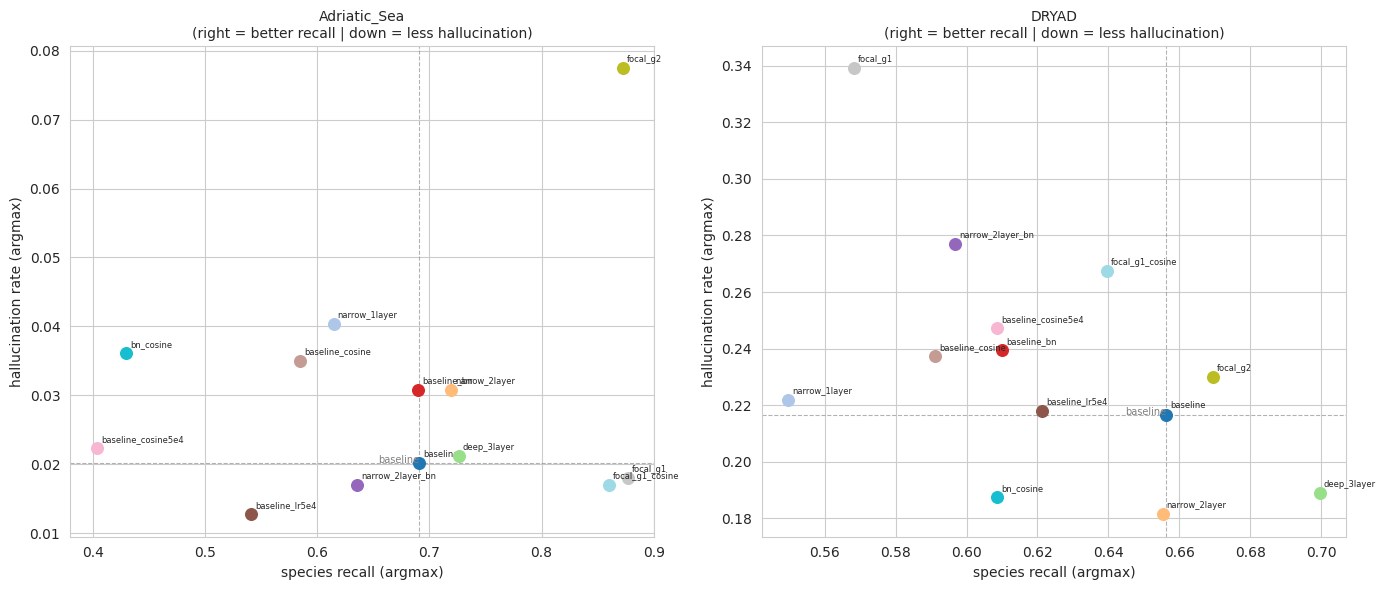

Saved → /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/arch_search/arch_recall_hallucin_scatter.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab20(np.linspace(0, 1, len(CONFIGS)))
cfg_color = {name: colors[i] for i, name in enumerate(CONFIGS)}

# Baseline reference lines
baseline_vals = summary[summary['config'] == 'baseline']

for ax, fold in zip(axes, SEARCH_HOLDOUTS):
    sub = summary[summary['held_out'] == fold]
    ref = baseline_vals[baseline_vals['held_out'] == fold]
    if not ref.empty:
        ax.axvline(ref['recall_argmax'].values[0],   color='grey', lw=0.8, ls='--', alpha=0.6)
        ax.axhline(ref['hallucin_argmax'].values[0], color='grey', lw=0.8, ls='--', alpha=0.6)

    for _, row in sub.iterrows():
        c = cfg_color[row['config']]
        ax.scatter(row['recall_argmax'], row['hallucin_argmax'],
                   color=c, s=70, zorder=3)
        ax.annotate(row['config'], (row['recall_argmax'], row['hallucin_argmax']),
                    fontsize=6, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

    ax.set_xlabel('species recall (argmax)', fontsize=10)
    ax.set_ylabel('hallucination rate (argmax)', fontsize=10)
    ax.set_title(f'{fold}\n(right = better recall | down = less hallucination)', fontsize=10)
    ax.annotate('baseline', (ref['recall_argmax'].values[0],
                              ref['hallucin_argmax'].values[0]),
                fontsize=7, color='grey', ha='right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'arch_recall_hallucin_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR}/arch_recall_hallucin_scatter.png")

## 12. Heatmap — recall and hallucination by config × fold

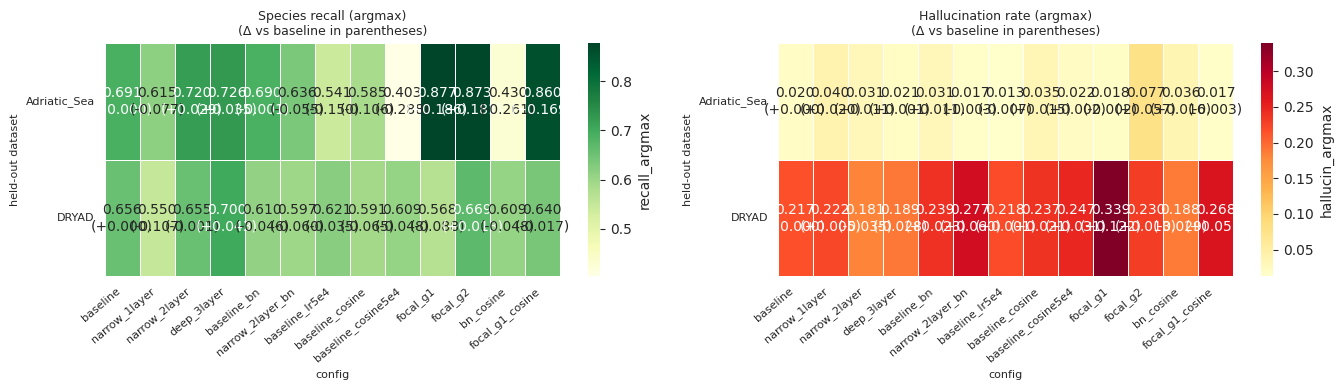

Saved → /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/arch_search/arch_recall_hallucin_heatmap.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(max(12, len(CONFIGS)*0.9 + 2), 4))

for ax, metric, cmap, title in [
    (axes[0], 'recall_argmax',   'YlGn',   'Species recall (argmax)'),
    (axes[1], 'hallucin_argmax', 'YlOrRd', 'Hallucination rate (argmax)'),
]:
    pivot = summary.pivot(index='held_out', columns='config', values=metric)
    # Order configs as defined in CONFIGS dict
    pivot = pivot[[c for c in CONFIGS if c in pivot.columns]]

    # Annotate with delta vs baseline
    base_row = pivot.get('baseline', None)
    if base_row is not None:
        annot = pivot.copy().round(3).astype(str)
        for fold in pivot.index:
            base_val = pivot.loc[fold, 'baseline'] if 'baseline' in pivot.columns else np.nan
            for cfg in pivot.columns:
                delta = pivot.loc[fold, cfg] - base_val
                sign  = '+' if delta >= 0 else ''
                annot.loc[fold, cfg] = f"{pivot.loc[fold, cfg]:.3f}\n({sign}{delta:.3f})"
    else:
        annot = pivot.round(3)

    sns.heatmap(pivot, cmap=cmap, annot=annot, fmt='', linewidths=0.4,
                ax=ax, cbar_kws={'label': metric})
    ax.set_title(title + '\n(Δ vs baseline in parentheses)', fontsize=9)
    ax.set_xlabel('config', fontsize=8)
    ax.set_ylabel('held-out dataset', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'arch_recall_hallucin_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR}/arch_recall_hallucin_heatmap.png")

## 13. Temperature diagnostic

T close to 1 = well-calibrated.  
T >> 1 = overconfident logits (nb3 pathology showed T=2.3–3.4 after focal+wider).

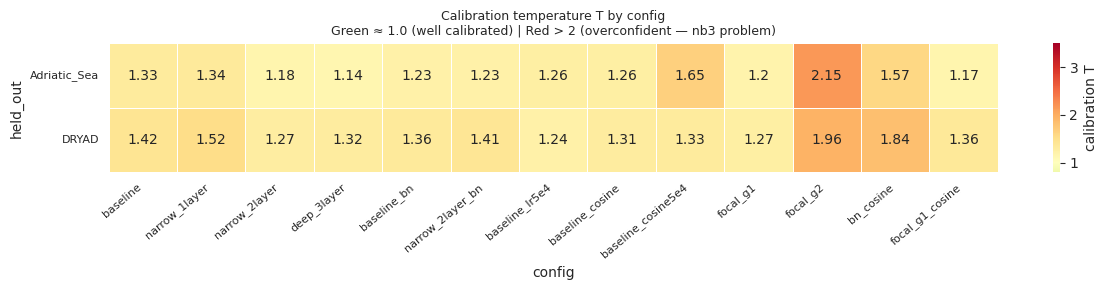

In [17]:
fig, ax = plt.subplots(figsize=(max(10, len(CONFIGS)*0.8 + 2), 3))

temp_pivot = summary.pivot(index='held_out', columns='config', values='temperature')
temp_pivot = temp_pivot[[c for c in CONFIGS if c in temp_pivot.columns]]

sns.heatmap(temp_pivot, cmap='RdYlGn_r', center=1.0, vmin=0.8, vmax=3.5,
            annot=temp_pivot.round(2), fmt='', linewidths=0.4, ax=ax,
            cbar_kws={'label': 'calibration T'})
ax.set_title('Calibration temperature T by config\n'
             'Green ≈ 1.0 (well calibrated) | Red > 2 (overconfident — nb3 problem)',
             fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'arch_temperature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Winner selection

A config wins if it achieves the best **mean recall** across both folds
without meaningfully increasing **mean hallucination** (tolerance +0.02 above baseline).

In [18]:
agg = (
    summary
    .groupby('config')
    .agg(
        mean_recall    = ('recall_argmax',   'mean'),
        mean_hallucin  = ('hallucin_argmax', 'mean'),
        mean_sp_f1     = ('sp_f1_argmax',    'mean'),
        mean_temp      = ('temperature',     'mean'),
        mean_val_f1    = ('val_macro_f1',    'mean'),
    )
    .reset_index()
    .sort_values('mean_recall', ascending=False)
)

# Mark baseline row for reference
baseline_recall   = agg.loc[agg['config'] == 'baseline', 'mean_recall'  ].values[0]
baseline_hallucin = agg.loc[agg['config'] == 'baseline', 'mean_hallucin'].values[0]

agg['delta_recall']   = agg['mean_recall']   - baseline_recall
agg['delta_hallucin'] = agg['mean_hallucin'] - baseline_hallucin
agg['pareto_ok']      = (
    (agg['mean_recall']   >= baseline_recall) &
    (agg['mean_hallucin'] <= baseline_hallucin + 0.02)
)

print("Aggregated results (sorted by mean recall across both folds):")
print(agg[[
    'config', 'mean_recall', 'delta_recall',
    'mean_hallucin', 'delta_hallucin',
    'mean_sp_f1', 'mean_temp', 'pareto_ok',
]].to_string(index=False))

winners = agg[agg['pareto_ok'] & (agg['config'] != 'baseline')]
if winners.empty:
    print("\n⚠  No config beat the baseline within the hallucination tolerance.")
else:
    print(f"\n✓ Configs that improve recall without hurting hallucination (>+0.02):")
    print(winners[['config','mean_recall','delta_recall','mean_hallucin','delta_hallucin']]
          .to_string(index=False))

Aggregated results (sorted by mean recall across both folds):
            config  mean_recall  delta_recall  mean_hallucin  delta_hallucin  mean_sp_f1  mean_temp  pareto_ok
          focal_g2      0.77100       0.09725        0.15365         0.03520     0.86700     2.0545      False
   focal_g1_cosine      0.74975       0.07600        0.14225         0.02380     0.85245     1.2675      False
          focal_g1      0.72255       0.04880        0.17860         0.06015     0.82955     1.2340      False
       deep_3layer      0.71285       0.03910        0.10510        -0.01335     0.83225     1.2275       True
     narrow_2layer      0.68750       0.01375        0.10610        -0.01235     0.81440     1.2250       True
          baseline      0.67375       0.00000        0.11845         0.00000     0.80490     1.3755       True
       baseline_bn      0.65005      -0.02370        0.13510         0.01665     0.78720     1.2950      False
  narrow_2layer_bn      0.61630      -0.05745     

## 15. Save all_results to disk (for downstream analysis)

In [19]:
import pickle

# Strip torch model objects before pickling (they can be retrained if needed)
results_to_save = {}
for cfg_name, fold_results in all_results.items():
    results_to_save[cfg_name] = {}
    for held_out, r in fold_results.items():
        r_save = {k: v for k, v in r.items()
                  if k not in ('model', 'scaler', 'temp_scaler', 'vec_scaler')}
        results_to_save[cfg_name][held_out] = r_save

out_pkl = OUT_DIR / 'arch_search_results.pkl'
with open(out_pkl, 'wb') as f:
    pickle.dump(results_to_save, f)

print(f"Results saved → {out_pkl}")
print(f"Summary CSV   → {OUT_DIR / 'arch_search_summary.csv'}")
print(f"\nDone. Best config(s) to carry forward into full LODO (nb6):")
if not winners.empty:
    for _, row in winners.iterrows():
        print(f"  {row['config']:25s}  recall={row['mean_recall']:.4f} (+{row['delta_recall']:.4f})  "
              f"hallucin={row['mean_hallucin']:.4f} ({row['delta_hallucin']:+.4f})")
        print(f"    config dict: {CONFIGS[row['config']]}")

Results saved → /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/arch_search/arch_search_results.pkl
Summary CSV   → /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/arch_search/arch_search_summary.csv

Done. Best config(s) to carry forward into full LODO (nb6):
  deep_3layer                recall=0.7128 (+0.0391)  hallucin=0.1051 (-0.0134)
    config dict: {'hidden': (512, 256, 128), 'dropout': 0.3, 'lr': 0.001, 'use_bn': False, 'scheduler': None, 'focal_gamma': 0.0}
  narrow_2layer              recall=0.6875 (+0.0137)  hallucin=0.1061 (-0.0123)
    config dict: {'hidden': (256, 128), 'dropout': 0.3, 'lr': 0.001, 'use_bn': False, 'scheduler': None, 'focal_gamma': 0.0}
